#01 - Data Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

train = pd.read_csv('../data/raw/train.csv')
stores = pd.read_csv('../data/raw/stores.csv')
oil = pd.read_csv('../data/raw/oil.csv')
holidays = pd.read_csv('../data/raw/holidays_events.csv')
transactions = pd.read_csv('../data/raw/transactions.csv')

print("Loaded")

Loaded


In [2]:
print(f"Shape: {train.shape}")
print(f"\nColumns: {list(train.columns)}")
train.head(10)

Shape: (3000888, 6)

Columns: ['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion']


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0
5,5,2013-01-01,1,BREAD/BAKERY,0.0,0
6,6,2013-01-01,1,CELEBRATION,0.0,0
7,7,2013-01-01,1,CLEANING,0.0,0
8,8,2013-01-01,1,DAIRY,0.0,0
9,9,2013-01-01,1,DELI,0.0,0


In [3]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         str    
 2   store_nbr    int64  
 3   family       str    
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 137.4 MB


In [4]:
train['date'] = pd.to_datetime(train['date'])
print(f"Από: {train['date'].min()}")
print(f"Μέχρι: {train['date'].max()}")
print(f"Διάρκεια: {(train['date'].max() - train['date'].min()).days} μέρες")

Από: 2013-01-01 00:00:00
Μέχρι: 2017-08-15 00:00:00
Διάρκεια: 1687 μέρες


In [5]:
print(f"Καταστήματα: {train['store_nbr'].nunique()}")
print(f"Οικογένειες προϊόντων: {train['family'].nunique()}")
print(f"\nΛίστα οικογενειών:")
print(train['family'].unique())

Καταστήματα: 54
Οικογένειες προϊόντων: 33

Λίστα οικογενειών:
<StringArray>
[                'AUTOMOTIVE',                  'BABY CARE',
                     'BEAUTY',                  'BEVERAGES',
                      'BOOKS',               'BREAD/BAKERY',
                'CELEBRATION',                   'CLEANING',
                      'DAIRY',                       'DELI',
                       'EGGS',               'FROZEN FOODS',
                  'GROCERY I',                 'GROCERY II',
                   'HARDWARE',         'HOME AND KITCHEN I',
        'HOME AND KITCHEN II',            'HOME APPLIANCES',
                  'HOME CARE',                 'LADIESWEAR',
            'LAWN AND GARDEN',                   'LINGERIE',
           'LIQUOR,WINE,BEER',                  'MAGAZINES',
                      'MEATS',              'PERSONAL CARE',
               'PET SUPPLIES',    'PLAYERS AND ELECTRONICS',
                    'POULTRY',             'PREPARED FOODS',
         

In [6]:
train['sales'].describe()

count    3.000888e+06
mean     3.577757e+02
std      1.101998e+03
min      0.000000e+00
25%      0.000000e+00
50%      1.100000e+01
75%      1.958473e+02
max      1.247170e+05
Name: sales, dtype: float64

In [7]:
zero_sales = (train['sales'] == 0).sum()
total = len(train)
print(f"Γραμμές με sales=0: {zero_sales:,} από {total:,} ({100*zero_sales/total:.1f}%)")

Γραμμές με sales=0: 939,130 από 3,000,888 (31.3%)


In [8]:
zero_by_family = train.groupby('family').apply(
    lambda x: (x['sales'] == 0).sum() / len(x) * 100
).sort_values(ascending=False)
print("Ποσοστό μηδενικών ανά οικογένεια:")
print(zero_by_family.round(1))

Ποσοστό μηδενικών ανά οικογένεια:
family
BOOKS                         97.0
BABY CARE                     94.1
SCHOOL AND OFFICE SUPPLIES    74.1
HOME APPLIANCES               73.5
LADIESWEAR                    59.8
MAGAZINES                     56.5
PET SUPPLIES                  54.6
HARDWARE                      47.9
LAWN AND GARDEN               46.8
PLAYERS AND ELECTRONICS       44.9
CELEBRATION                   43.6
HOME CARE                     40.9
HOME AND KITCHEN II           34.7
HOME AND KITCHEN I            34.6
PRODUCE                       28.4
BEAUTY                        26.3
SEAFOOD                       19.4
LIQUOR,WINE,BEER              17.9
LINGERIE                      16.0
AUTOMOTIVE                    12.8
GROCERY II                    12.1
FROZEN FOODS                   8.1
PREPARED FOODS                 8.1
POULTRY                        8.1
PERSONAL CARE                  8.1
GROCERY I                      8.1
EGGS                           8.1
DELI          

In [9]:
zero_by_store = train.groupby('store_nbr').apply(
    lambda x: (x['sales'] == 0).sum() / len(x) * 100
).sort_values(ascending=False)
print("Top 10 stores με τα περισσότερα μηδενικά:")
print(zero_by_store.head(10).round(1))
print("\nBottom 10 stores με τα λιγότερα μηδενικά:")
print(zero_by_store.tail(10).round(1))

Top 10 stores με τα περισσότερα μηδενικά:
store_nbr
52    93.5
22    68.5
42    62.2
21    61.3
29    57.2
20    54.5
53    43.2
32    39.6
35    39.1
54    34.7
dtype: float64

Bottom 10 stores με τα λιγότερα μηδενικά:
store_nbr
7     20.8
50    20.7
51    20.1
8     19.9
45    19.4
49    19.3
46    19.3
47    19.0
3     18.1
44    17.9
dtype: float64


In [10]:
# Δείγμα 20 γραμμών με μηδενικά
train[train['sales'] == 0].sample(20, random_state=42)

,id,date,store_nbr,family,sales,onpromotion
882549,882549,2014-05-12,21,PRODUCE,0.0,0
866462,866462,2014-05-03,20,HARDWARE,0.0,0
385819,385819,2013-08-05,34,HOME AND KITCHEN II,0.0,0
1323139,1323139,2015-01-15,34,BOOKS,0.0,0
1605375,1605375,2015-06-22,52,MEATS,0.0,0
1532250,1532250,2015-05-12,50,PLAYERS AND ELECTRONICS,0.0,0
1518430,1518430,2015-05-05,14,BABY CARE,0.0,0
603387,603387,2013-12-05,39,HOME AND KITCHEN I,0.0,0
474112,474112,2013-09-24,12,BABY CARE,0.0,0
801322,801322,2014-03-27,42,HOME AND KITCHEN II,0.0,0


In [11]:
# Για κάθε ζευγάρι (store, family), πόσο μέσο όρο πωλήσεων έχει
pair_avg = train.groupby(['store_nbr', 'family'])['sales'].mean()

# Πόσα ζευγάρια έχουν πάντα 0;
total_pairs = len(pair_avg)
always_zero = (pair_avg == 0).sum()
mostly_zero = (pair_avg < 1).sum()  # σχεδόν πάντα 0

print(f"Συνολικά (store, family) ζευγάρια: {total_pairs}")  # θα είναι 54 × 33 = 1,782
print(f"Always-zero ζευγάρια: {always_zero} ({100*always_zero/total_pairs:.1f}%)")
print(f"Σχεδόν-always-zero (avg<1): {mostly_zero} ({100*mostly_zero/total_pairs:.1f}%)")

Συνολικά (store, family) ζευγάρια: 1782
Always-zero ζευγάρια: 53 (3.0%)
Σχεδόν-always-zero (avg<1): 299 (16.8%)


In [12]:
# Average sales per family για το store 52
store_52 = train[train['store_nbr'] == 52].groupby('family')['sales'].agg(['mean', 'sum'])
store_52_sorted = store_52.sort_values('sum', ascending=False)
print("Store 52 - πωλήσεις ανά οικογένεια:")
print(store_52_sorted)

Store 52 - πωλήσεις ανά οικογένεια:
                                  mean            sum
family                                               
GROCERY I                   437.181116  736213.000000
PRODUCE                     345.105530  581157.713300
BEVERAGES                   319.356295  537796.000000
CLEANING                    119.602732  201411.000000
DAIRY                        83.482185  140584.000000
BREAD/BAKERY                 57.910236   97520.837100
MEATS                        35.260641   59378.919950
POULTRY                      34.657403   58363.066890
PERSONAL CARE                26.989311   45450.000000
DELI                         26.522817   44664.423960
HOME CARE                    26.334323   44347.000000
FROZEN FOODS                 24.122381   40622.090020
EGGS                         14.846793   25002.000000
LIQUOR,WINE,BEER             14.697150   24750.000000
PREPARED FOODS                9.472213   15951.206030
LAWN AND GARDEN               4.576010    7706

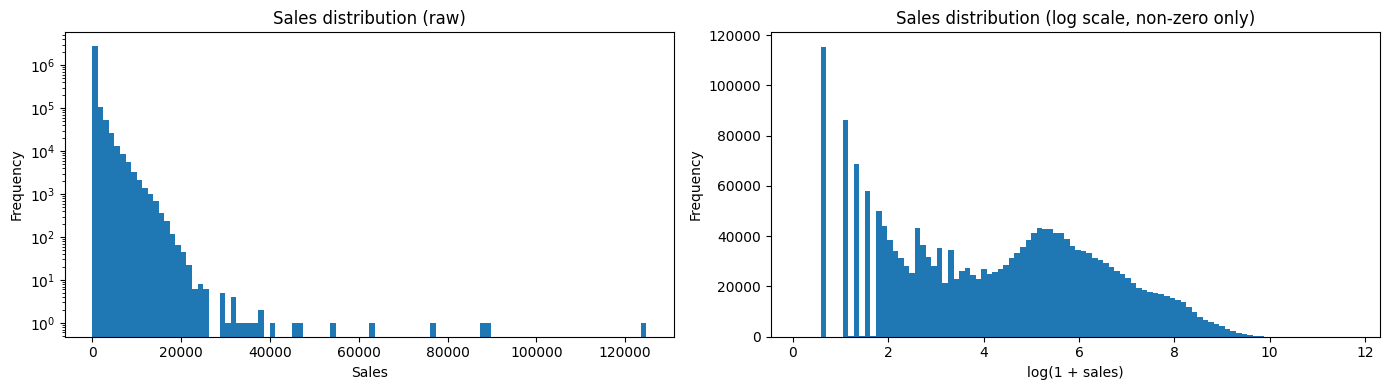

In [13]:
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw distribution
axes[0].hist(train['sales'], bins=100)
axes[0].set_title('Sales distribution (raw)')
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Frequency')
axes[0].set_yscale('log')  # log scale γιατί τα 0 κυριαρχούν

# Log distribution (μόνο για non-zero)
non_zero_sales = train.loc[train['sales'] > 0, 'sales']
axes[1].hist(np.log1p(non_zero_sales), bins=100)
axes[1].set_title('Sales distribution (log scale, non-zero only)')
axes[1].set_xlabel('log(1 + sales)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [14]:
for col in stores.columns:
    if stores[col].dtype == 'object' or stores[col].dtype == 'str':
        print(f"{col}: {stores[col].nunique()} μοναδικές → {sorted(stores[col].unique())}")
    elif col != 'store_nbr':
        print(f"{col}: range [{stores[col].min()}, {stores[col].max()}], {stores[col].nunique()} μοναδικές")

city: 22 μοναδικές → ['Ambato', 'Babahoyo', 'Cayambe', 'Cuenca', 'Daule', 'El Carmen', 'Esmeraldas', 'Guaranda', 'Guayaquil', 'Ibarra', 'Latacunga', 'Libertad', 'Loja', 'Machala', 'Manta', 'Playas', 'Puyo', 'Quevedo', 'Quito', 'Riobamba', 'Salinas', 'Santo Domingo']
state: 16 μοναδικές → ['Azuay', 'Bolivar', 'Chimborazo', 'Cotopaxi', 'El Oro', 'Esmeraldas', 'Guayas', 'Imbabura', 'Loja', 'Los Rios', 'Manabi', 'Pastaza', 'Pichincha', 'Santa Elena', 'Santo Domingo de los Tsachilas', 'Tungurahua']
type: 5 μοναδικές → ['A', 'B', 'C', 'D', 'E']
cluster: range [1, 17], 17 μοναδικές


In [15]:
print(f"Shape: {oil.shape}")
print(f"\nColumns: {list(oil.columns)}")
print(f"\nDtypes:")
print(oil.dtypes)
print(f"\nMissing values:")
print(oil.isnull().sum())
print(f"\nFirst rows:")
oil.head(10)

Shape: (1218, 2)

Columns: ['date', 'dcoilwtico']

Dtypes:
date              str
dcoilwtico    float64
dtype: object

Missing values:
date           0
dcoilwtico    43
dtype: int64

First rows:


,date,dcoilwtico
0,2013-01-01,NaN
1,2013-01-02,93.14
2,2013-01-03,92.97
3,2013-01-04,93.12
4,2013-01-07,93.20
5,2013-01-08,93.21
6,2013-01-09,93.08
7,2013-01-10,93.81
8,2013-01-11,93.60
9,2013-01-14,94.27


In [16]:
oil['date'] = pd.to_datetime(oil['date'])
print(f"Oil από: {oil['date'].min()} έως {oil['date'].max()}")
print(f"Train από: {train['date'].min()} έως {train['date'].max()}")
print(f"\nΣτατιστικά τιμής πετρελαίου:")
print(oil['dcoilwtico'].describe())

Oil από: 2013-01-01 00:00:00 έως 2017-08-31 00:00:00
Train από: 2013-01-01 00:00:00 έως 2017-08-15 00:00:00

Στατιστικά τιμής πετρελαίου:
count    1175.000000
mean       67.714366
std        25.630476
min        26.190000
25%        46.405000
50%        53.190000
75%        95.660000
max       110.620000
Name: dcoilwtico, dtype: float64


In [17]:
print(f"Shape: {holidays.shape}")
print(f"Columns: {list(holidays.columns)}")
print(f"Missing: {holidays.isnull().sum().sum()}")
print(f"\nFirst rows:")
holidays.head(10)

Shape: (350, 6)
Columns: ['date', 'type', 'locale', 'locale_name', 'description', 'transferred']
Missing: 0

First rows:


,date,type,locale,locale_name,description,transferred
0,2012-03-02,Holiday,Local,Manta,Fundacion de Manta,False
1,2012-04-01,Holiday,Regional,Cotopaxi,Provincializacion de Cotopaxi,False
2,2012-04-12,Holiday,Local,Cuenca,Fundacion de Cuenca,False
3,2012-04-14,Holiday,Local,Libertad,Cantonizacion de Libertad,False
4,2012-04-21,Holiday,Local,Riobamba,Cantonizacion de Riobamba,False
5,2012-05-12,Holiday,Local,Puyo,Cantonizacion del Puyo,False
6,2012-06-23,Holiday,Local,Guaranda,Cantonizacion de Guaranda,False
7,2012-06-25,Holiday,Regional,Imbabura,Provincializacion de Imbabura,False
8,2012-06-25,Holiday,Local,Latacunga,Cantonizacion de Latacunga,False
9,2012-06-25,Holiday,Local,Machala,Fundacion de Machala,False


In [18]:
for col in ['type', 'locale', 'locale_name', 'transferred']:
    print(f"\n{col}: {holidays[col].nunique()} μοναδικές")
    print(holidays[col].value_counts())


type: 6 μοναδικές
type
Holiday       221
Event          56
Additional     51
Transfer       12
Bridge          5
Work Day        5
Name: count, dtype: int64

locale: 3 μοναδικές
locale
National    174
Local       152
Regional     24
Name: count, dtype: int64

locale_name: 24 μοναδικές
locale_name
Ecuador                           174
Quito                              13
Riobamba                           12
Guaranda                           12
Latacunga                          12
Ambato                             12
Guayaquil                          11
Cuenca                              7
Ibarra                              7
Manta                               6
Cotopaxi                            6
Libertad                            6
Puyo                                6
Imbabura                            6
Machala                             6
Santo Domingo                       6
El Carmen                           6
Cayambe                             6
Esmeraldas       

In [19]:
print(f"Shape: {transactions.shape}")
print(f"Columns: {list(transactions.columns)}")
print(f"Missing: {transactions.isnull().sum().sum()}")
print(f"\nFirst rows:")
transactions.head(10)
print(f"\nΣτατιστικά:")
transactions['transactions'].describe()

Shape: (83488, 3)
Columns: ['date', 'store_nbr', 'transactions']
Missing: 0

First rows:

Στατιστικά:


count    83488.000000
mean      1694.602158
std        963.286644
min          5.000000
25%       1046.000000
50%       1393.000000
75%       2079.000000
max       8359.000000
Name: transactions, dtype: float64